#### Interpolation in Latent Space
1) Linear Interpolation between any two latent vector z1 and z2.
2) Non Linear Interpolation (SLERP Algorithm, traversal on hypersphere).


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_generator_name = 'perfect_generator.pth' # Change the name of generator saved during training of GAN.
latent_dim = 50 # Take value same as taken in Generator during training of GAN.

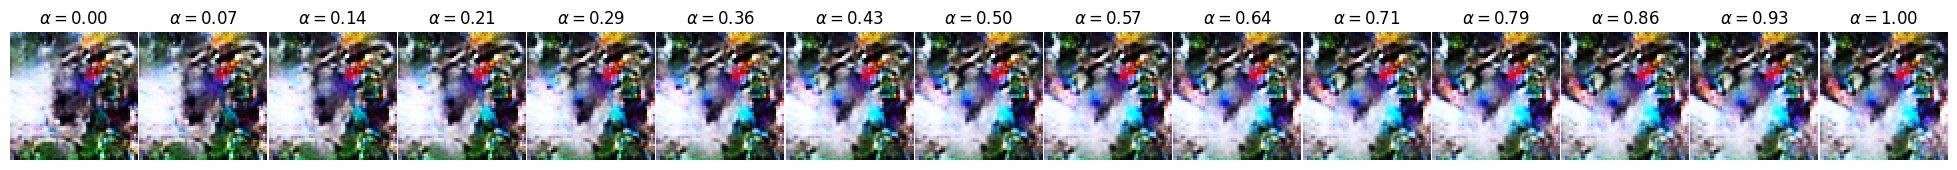

In [16]:
torch.manual_seed(97)
z1 = torch.randn(1, latent_dim, 1, 1, device=device)
z2 = torch.randn(1, latent_dim, 1, 1, device=device)
G = torch.load(save_generator_name,weights_only=False)
n_images = 15
alpha = torch.linspace(0, 1, n_images).to(device)
plt.figure(figsize=(25,3))
for i in range(n_images):
    z = alpha[i] * z1 + (1 - alpha[i]) * z2
    plt.subplot(1, n_images, i + 1)
    plt.title(r'$\alpha = %1.2f$' % alpha[i])  # Use LaTeX formatting for alpha
    with torch.no_grad():
        img = G(z).detach().cpu().squeeze().permute(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1]
        plt.imshow(img)

    plt.axis('off')
# Adjust layout to reduce white space
plt.subplots_adjust(wspace=0.01, hspace=0.0)
plt.show()


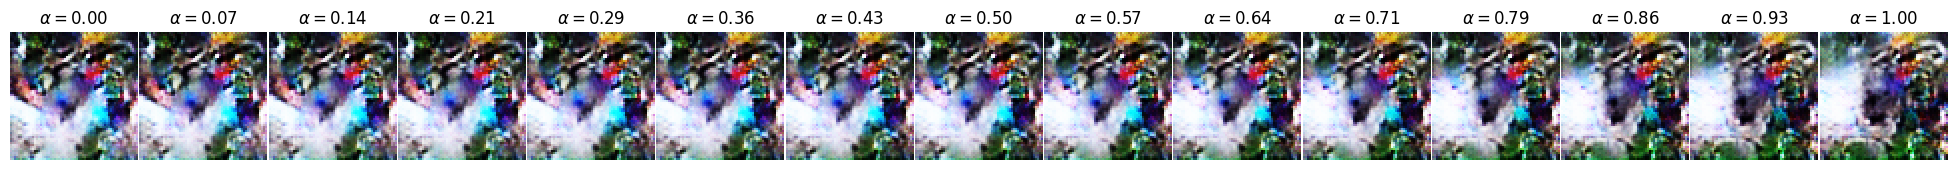

In [17]:
# Hypersphere traversal in latent 
dot_product = torch.mul(z1[0,:,0,0], z2[0,:,0,0]).sum()
# print(dot_product)

# Compute the norms (magnitudes) of the vectors
norm_A = torch.norm(z1)
norm_B = torch.norm(z2)
# Compute cos(theta)
cos_theta = dot_product / (norm_A * norm_B)

# Ensure cos_theta is in the range [-1, 1] to avoid numerical issues
cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

# Compute sin(theta) using the identity: sin^2(theta) + cos^2(theta) = 1
sin_theta = torch.sqrt(1 - cos_theta ** 2)
# Compute SLERP interpolation
 # Handle the case where vectors are almost identical to avoid division by zero
plt.figure(figsize=(25,3))
 
for i in range(n_images):
    z = ((torch.sin(1-alpha[i]))/(sin_theta))*z1 + ((torch.sin(alpha[i]))/(sin_theta))*z2
    plt.subplot(1, n_images, i + 1)
    plt.title(r'$\alpha = %1.2f$' % alpha[i])  # Use LaTeX formatting for alpha
    with torch.no_grad():
        img = G(z).detach().cpu().squeeze().permute(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1]
        plt.imshow(img)

    plt.axis('off')
# Adjust layout to reduce white space
plt.subplots_adjust(wspace=0.01, hspace=0.0)
plt.show()



#### Observation:
In our example, while doing linear interpolation image stays within the image manifold so not an issue.
- but sometimes one may end up some images which are outside the image manifold. 
    Thus, sometimes we may need non-linear interpolation between two latent datapoints.
    
SLERP algorithm is latent space traversal on the surface of hypersphere. \
We used this algorithm in second calculation above for illustration.
Both giving almost similar image traversals.